# IoT Intrusion Detection Project
## Milestone 3 — Model Training

This notebook trains and compares four classifiers on the preprocessed IoT traffic data:
Logistic Regression (baseline), Random Forest, HistGradientBoosting, and a PyTorch MLP.

**Protocol.** All four models are evaluated on the **validation** set only. The test set is
held out and used **once**, at the end of the notebook, to evaluate the single model selected
on validation. Model selection is based on **macro F1** (not accuracy), because the dataset is
class-imbalanced and minority attack classes matter as much as benign traffic.

**Class imbalance handling.** All models are trained with class weighting so that the rare
attack classes (e.g. SqlInjection, DictionaryBruteForce) are not ignored by the optimizer.

**Security-specific metric.** In addition to accuracy and macro F1, we also track the
**false positive rate on benign traffic** — the fraction of benign flows that get flagged as
an attack. A noisy IDS that cries wolf is not operationally useful.

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
from sklearn.metrics import precision_recall_fscore_support
from IPython.display import display

def show_recall_table(y_true, y_pred, model_name, class_names):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, zero_division=0
    )
    df_metrics = pd.DataFrame({
        "class": class_names,
        "recall": recall,
        "precision": precision,
        "f1_score": f1,
        "support": support,
    }).sort_values("recall")

    print(f"\n{model_name}")
    display(df_metrics)
    return df_metrics

In [3]:
X_train = np.load("../data/processed/X_train_scaled.npy")
X_val   = np.load("../data/processed/X_val_scaled.npy")
X_test  = np.load("../data/processed/X_test_scaled.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val   = np.load("../data/processed/y_val.npy")
y_test  = np.load("../data/processed/y_test.npy")

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (759529, 39)
X_val:   (162758, 39)
X_test:  (162760, 39)
y_train: (759529,)
y_val:   (162758,)
y_test:  (162760,)


In [4]:
class_names = [
    "BenignTraffic",
    "DDoS-ICMP_Flood",
    "DictionaryBruteForce",
    "DoS-SYN_Flood",
    "MITM-ArpSpoofing",
    "Mirai-greeth_flood",
    "Recon-PortScan",
    "SqlInjection",
]
BENIGN_LABEL = class_names.index("BenignTraffic")

# Sanity check: label set must match class_names
assert len(class_names) == len(np.unique(y_train)), (
    f"class_names has {len(class_names)} entries but y_train has "
    f"{len(np.unique(y_train))} unique labels"
)

# Class distribution in the training set (to justify class weighting)
unique, counts = np.unique(y_train, return_counts=True)
print("Training class distribution:")
for c, n in zip(unique, counts):
    print(f"  {c} {class_names[c]:<22s} {n:>8d}  ({n/len(y_train):.2%})")

Training class distribution:
  0 BenignTraffic            252605  (33.26%)
  1 DDoS-ICMP_Flood           93009  (12.25%)
  2 DictionaryBruteForce       9143  (1.20%)
  3 DoS-SYN_Flood            161653  (21.28%)
  4 MITM-ArpSpoofing         159888  (21.05%)
  5 Mirai-greeth_flood        23390  (3.08%)
  6 Recon-PortScan            56170  (7.40%)
  7 SqlInjection               3671  (0.48%)


### Helper: confusion-matrix plot

Defined once here and reused for every model so each section stays short and consistent.

In [5]:
def plot_cm(cm, title, normalize=False):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    fmt = ".2f" if normalize else "d"

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Helper: false-positive rate on benign traffic

The fraction of truly-benign flows that get flagged as *any* attack class. This is
the operational "cry wolf" metric called out by the project brief.

In [6]:
def fpr_on_benign(y_true, y_pred, benign_label=BENIGN_LABEL):
    mask = (y_true == benign_label)
    if mask.sum() == 0:
        return float("nan")
    return (y_pred[mask] != benign_label).mean()

## 2. Logistic Regression (baseline)

A simple linear baseline to anchor the comparison. `class_weight="balanced"` reweights
the loss so minority classes are not ignored.

In [7]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
log_reg.fit(X_train, y_train)
print("Logistic Regression trained successfully")

/Users/joseazzi/miniconda3/envs/iot-ids/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression trained successfully


In [8]:
y_val_pred_log = log_reg.predict(X_val)

show_recall_table(
    y_val,
    y_val_pred_log,
    "Logistic Regression - Validation",
    class_names,
)

print("Validation Accuracy:        ", accuracy_score(y_val, y_val_pred_log))
print("Validation Macro F1:        ", f1_score(y_val, y_val_pred_log, average="macro"))
print("Validation FPR on benign:   ", fpr_on_benign(y_val, y_val_pred_log))


Logistic Regression - Validation


,class,recall,precision,f1_score,support
2,DictionaryBruteForce,0.412455,0.068307,0.117203,1959
6,Recon-PortScan,0.413226,0.704632,0.520947,12037
0,BenignTraffic,0.467504,0.824112,0.596579,54130
4,MITM-ArpSpoofing,0.594098,0.643087,0.617623,34262
7,SqlInjection,0.642948,0.023064,0.044530,787
5,Mirai-greeth_flood,0.998005,0.998005,0.998005,5012
3,DoS-SYN_Flood,0.999567,1.000000,0.999783,34640
1,DDoS-ICMP_Flood,0.999649,0.999448,0.999548,19931


Validation Accuracy:         0.6850661718625198
Validation Macro F1:         0.6117774570499954
Validation FPR on benign:    0.5324958433401071


In [9]:
print(classification_report(y_val, y_val_pred_log, target_names=class_names, zero_division=0))

                      precision    recall  f1-score   support

       BenignTraffic       0.82      0.47      0.60     54130
     DDoS-ICMP_Flood       1.00      1.00      1.00     19931
DictionaryBruteForce       0.07      0.41      0.12      1959
       DoS-SYN_Flood       1.00      1.00      1.00     34640
    MITM-ArpSpoofing       0.64      0.59      0.62     34262
  Mirai-greeth_flood       1.00      1.00      1.00      5012
      Recon-PortScan       0.70      0.41      0.52     12037
        SqlInjection       0.02      0.64      0.04       787

            accuracy                           0.69    162758
           macro avg       0.66      0.69      0.61    162758
        weighted avg       0.83      0.69      0.73    162758



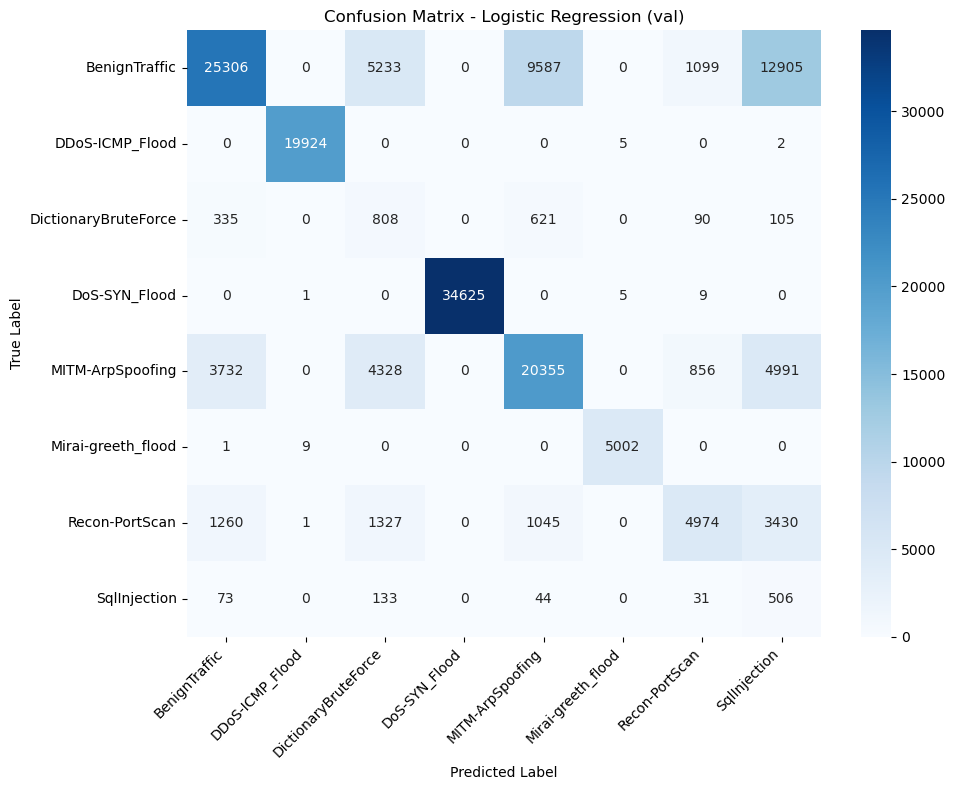

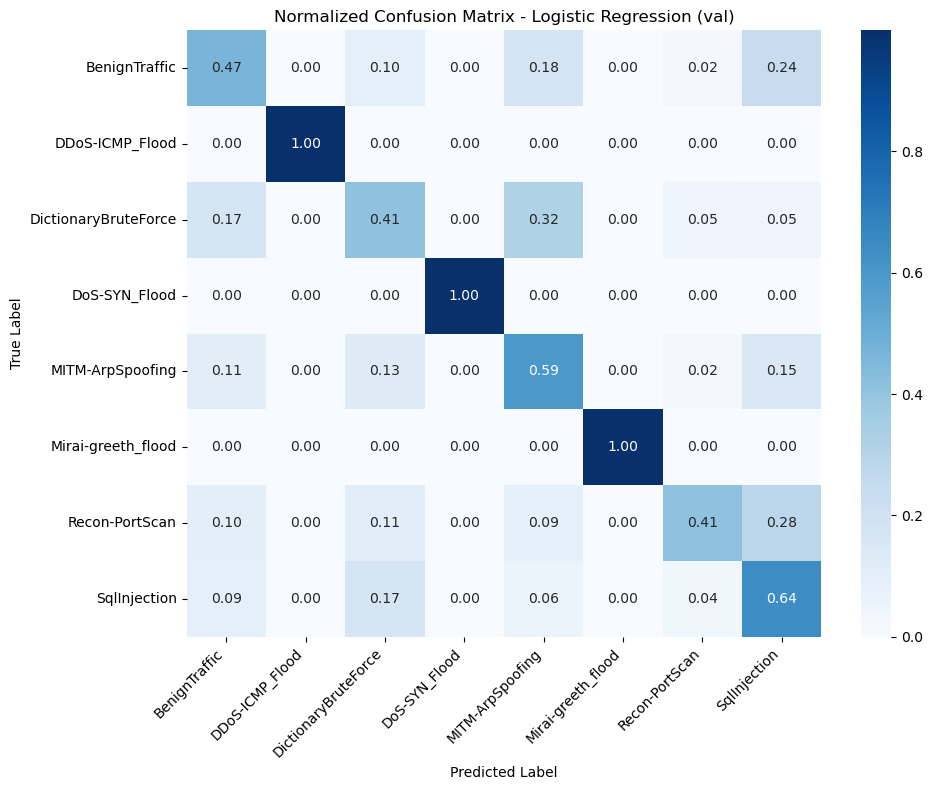

In [10]:
cm_log_val = confusion_matrix(y_val, y_val_pred_log)
plot_cm(cm_log_val, "Confusion Matrix - Logistic Regression (val)")
plot_cm(cm_log_val, "Normalized Confusion Matrix - Logistic Regression (val)", normalize=True)

## 3. Random Forest

A bagged tree ensemble — usually a strong default for tabular data. Using
`class_weight="balanced"` and 200 trees.

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


In [12]:
y_val_pred_rf = rf_model.predict(X_val)

show_recall_table(
    y_val,
    y_val_pred_rf,
    "Random Forest - Validation",
    class_names,
)

print("Validation Accuracy:        ", accuracy_score(y_val, y_val_pred_rf))
print("Validation Macro F1:        ", f1_score(y_val, y_val_pred_rf, average="macro"))
print("Validation FPR on benign:   ", fpr_on_benign(y_val, y_val_pred_rf))


Random Forest - Validation


,class,recall,precision,f1_score,support
7,SqlInjection,0.054638,0.462366,0.097727,787
2,DictionaryBruteForce,0.250128,0.696023,0.368006,1959
6,Recon-PortScan,0.485337,0.864713,0.621721,12037
4,MITM-ArpSpoofing,0.859874,0.961992,0.908071,34262
0,BenignTraffic,0.974266,0.811363,0.885384,54130
5,Mirai-greeth_flood,0.994613,0.999799,0.997199,5012
3,DoS-SYN_Flood,0.999942,0.999942,0.999942,34640
1,DDoS-ICMP_Flood,0.999950,0.998697,0.999323,19931


Validation Accuracy:         0.9100996571597095
Validation Macro F1:         0.7346717085467694
Validation FPR on benign:    0.025734343247736928


In [13]:
print(classification_report(y_val, y_val_pred_rf, target_names=class_names, zero_division=0))

                      precision    recall  f1-score   support

       BenignTraffic       0.81      0.97      0.89     54130
     DDoS-ICMP_Flood       1.00      1.00      1.00     19931
DictionaryBruteForce       0.70      0.25      0.37      1959
       DoS-SYN_Flood       1.00      1.00      1.00     34640
    MITM-ArpSpoofing       0.96      0.86      0.91     34262
  Mirai-greeth_flood       1.00      0.99      1.00      5012
      Recon-PortScan       0.86      0.49      0.62     12037
        SqlInjection       0.46      0.05      0.10       787

            accuracy                           0.91    162758
           macro avg       0.85      0.70      0.73    162758
        weighted avg       0.91      0.91      0.90    162758



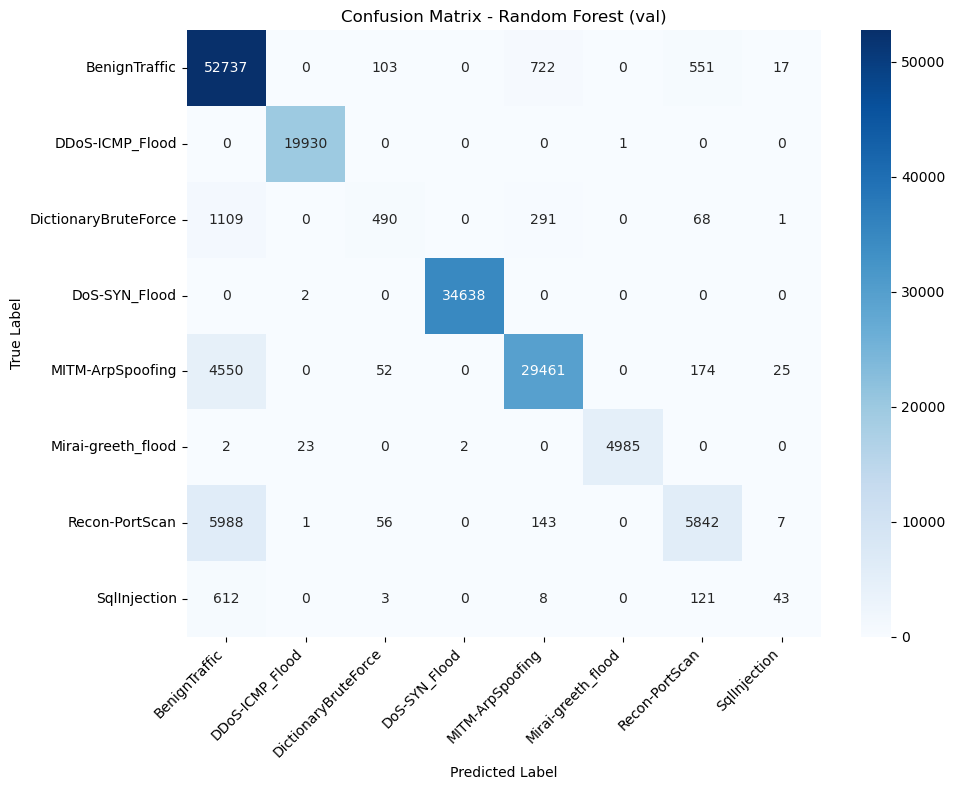

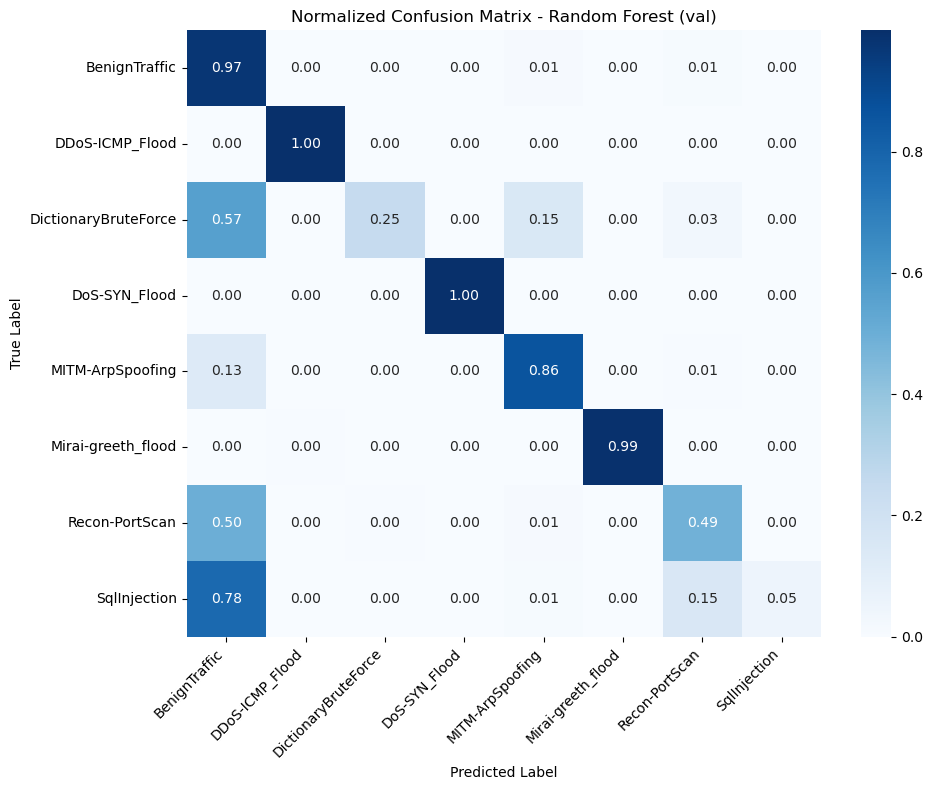

In [14]:
cm_rf_val = confusion_matrix(y_val, y_val_pred_rf)
plot_cm(cm_rf_val, "Confusion Matrix - Random Forest (val)")
plot_cm(cm_rf_val, "Normalized Confusion Matrix - Random Forest (val)", normalize=True)

## 4. HistGradientBoosting

A boosted tree ensemble. `HistGradientBoostingClassifier` does not accept `class_weight`
directly, so we pass per-sample weights computed with `compute_sample_weight("balanced", ...)`.

In [15]:
sample_weights = compute_sample_weight("balanced", y_train)

gb_model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    random_state=42,
)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("HistGradientBoosting trained successfully")

HistGradientBoosting trained successfully


In [16]:
y_val_pred_gb = gb_model.predict(X_val)

show_recall_table(
    y_val,
    y_val_pred_gb,
    "HistGradientBoosting - Validation",
    class_names,
)

print("Validation Accuracy:        ", accuracy_score(y_val, y_val_pred_gb))
print("Validation Macro F1:        ", f1_score(y_val, y_val_pred_gb, average="macro"))
print("Validation FPR on benign:   ", fpr_on_benign(y_val, y_val_pred_gb))


HistGradientBoosting - Validation


,class,recall,precision,f1_score,support
6,Recon-PortScan,0.466811,0.564894,0.511190,12037
7,SqlInjection,0.602287,0.035028,0.066206,787
2,DictionaryBruteForce,0.638591,0.134213,0.221809,1959
0,BenignTraffic,0.696693,0.911534,0.789764,54130
4,MITM-ArpSpoofing,0.858473,0.956551,0.904862,34262
3,DoS-SYN_Flood,0.932679,0.998301,0.964375,34640
5,Mirai-greeth_flood,0.987829,0.889029,0.935828,5012
1,DDoS-ICMP_Flood,0.993126,0.994424,0.993774,19931


Validation Accuracy:         0.808083166418855
Validation Macro F1:         0.6734759504104604
Validation FPR on benign:    0.3033068538703122


In [17]:
print(classification_report(y_val, y_val_pred_gb, target_names=class_names, zero_division=0))

                      precision    recall  f1-score   support

       BenignTraffic       0.91      0.70      0.79     54130
     DDoS-ICMP_Flood       0.99      0.99      0.99     19931
DictionaryBruteForce       0.13      0.64      0.22      1959
       DoS-SYN_Flood       1.00      0.93      0.96     34640
    MITM-ArpSpoofing       0.96      0.86      0.90     34262
  Mirai-greeth_flood       0.89      0.99      0.94      5012
      Recon-PortScan       0.56      0.47      0.51     12037
        SqlInjection       0.04      0.60      0.07       787

            accuracy                           0.81    162758
           macro avg       0.69      0.77      0.67    162758
        weighted avg       0.91      0.81      0.85    162758



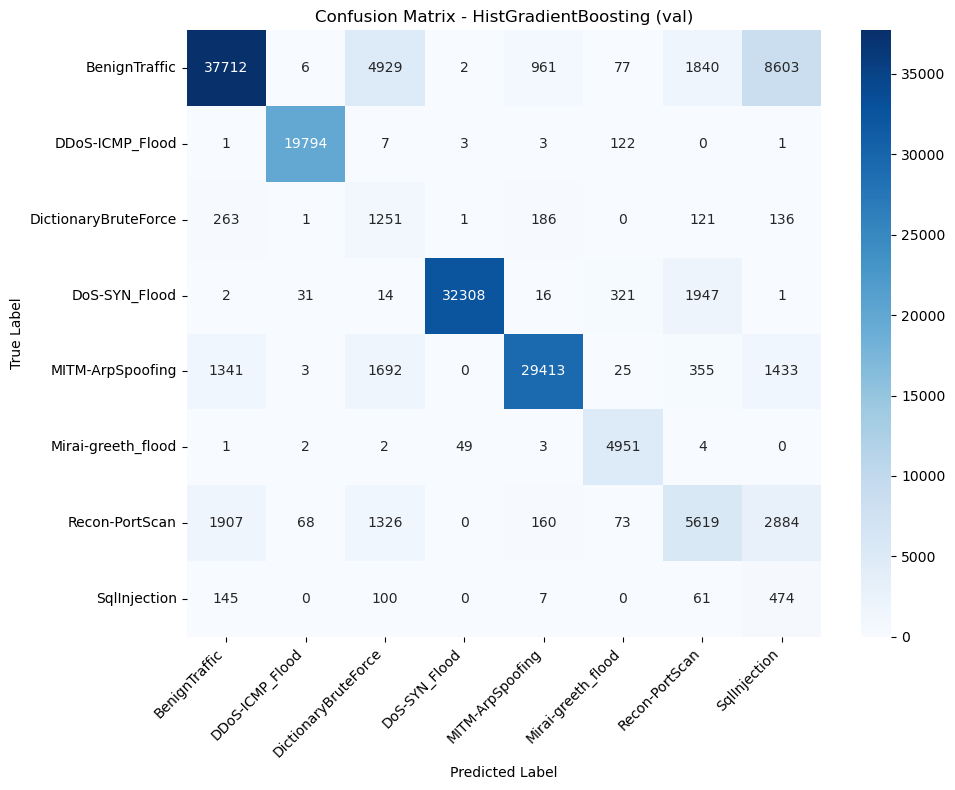

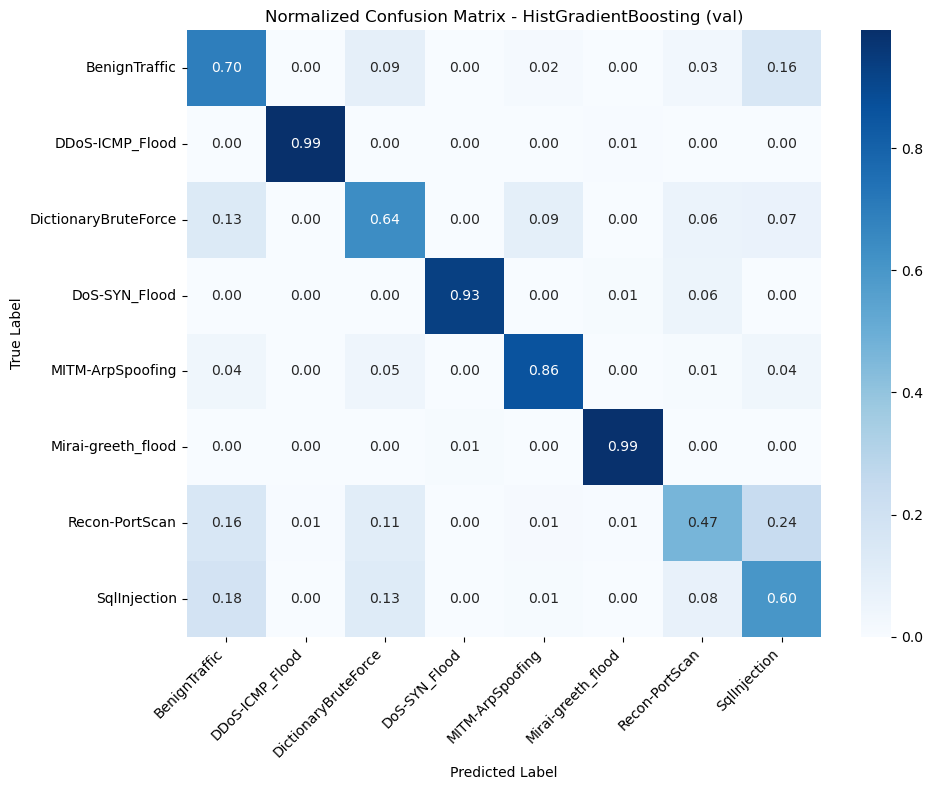

In [18]:
cm_gb_val = confusion_matrix(y_val, y_val_pred_gb)
plot_cm(cm_gb_val, "Confusion Matrix - HistGradientBoosting (val)")
plot_cm(cm_gb_val, "Normalized Confusion Matrix - HistGradientBoosting (val)", normalize=True)

## 5. PyTorch MLP

A small fully-connected network built in PyTorch. Design choices:

- Hidden layers: `(128, 64)` with ReLU activations.
- Loss: `CrossEntropyLoss` with per-class weights (inverse class frequency) — this is the
  PyTorch equivalent of scikit-learn's `class_weight="balanced"`.
- Optimizer: Adam, learning rate `1e-3`.
- **Early stopping** on validation loss (patience = 5 epochs), so `max_epochs` is an
  upper bound, not a target.
- To avoid leakage, the MLP's early-stopping signal is taken from a small split carved
  out of `X_train`, **not** from `X_val`. This keeps `X_val` pristine for cross-model
  selection in section 6.

The `TorchMLPClassifier` wrapper exposes `.fit()`, `.predict()`, and `.predict_proba()`
so it plugs into the same downstream code as the scikit-learn models.

In [19]:
class TorchMLPClassifier:
    """Minimal sklearn-style wrapper around a PyTorch MLP."""

    def __init__(
        self,
        input_dim,
        n_classes,
        hidden_layers=(128, 64),
        lr=1e-3,
        batch_size=1024,
        max_epochs=50,
        patience=5,
        class_weights=None,
        device=None,
        random_state=42,
    ):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.hidden_layers = hidden_layers
        self.lr = lr
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.class_weights = class_weights
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.random_state = random_state
        self._build()

    def _build(self):
        torch.manual_seed(self.random_state)
        layers = []
        prev = self.input_dim
        for h in self.hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, self.n_classes))
        self.model = nn.Sequential(*layers).to(self.device)

    def _make_loader(self, X, y, shuffle):
        ds = TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
        )
        return DataLoader(ds, batch_size=self.batch_size, shuffle=shuffle)

    def _eval_loss(self, loader, criterion):
        self.model.eval()
        total, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                logits = self.model(xb)
                loss = criterion(logits, yb)
                total += loss.item() * xb.size(0)
                n += xb.size(0)
        return total / n

    def fit(self, X_train, y_train, X_val=None, y_val=None, verbose=True):
        train_loader = self._make_loader(X_train, y_train, shuffle=True)
        val_loader = self._make_loader(X_val, y_val, shuffle=False) if X_val is not None else None

        if self.class_weights is not None:
            w = torch.tensor(self.class_weights, dtype=torch.float32).to(self.device)
            criterion = nn.CrossEntropyLoss(weight=w)
        else:
            criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        best_val = float("inf")
        best_state = None
        bad_epochs = 0

        for epoch in range(1, self.max_epochs + 1):
            self.model.train()
            running, n = 0.0, 0
            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                optimizer.zero_grad()
                logits = self.model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                running += loss.item() * xb.size(0)
                n += xb.size(0)
            train_loss = running / n

            if val_loader is not None:
                val_loss = self._eval_loss(val_loader, criterion)
                if verbose:
                    print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
                if val_loss < best_val - 1e-5:
                    best_val = val_loss
                    best_state = {k: v.detach().clone() for k, v in self.model.state_dict().items()}
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                    if bad_epochs >= self.patience:
                        if verbose:
                            print(f"Early stopping at epoch {epoch}")
                        break
            elif verbose:
                print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f}")

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    def predict_proba(self, X):
        self.model.eval()
        out = []
        loader = DataLoader(
            TensorDataset(torch.tensor(X, dtype=torch.float32)),
            batch_size=self.batch_size,
            shuffle=False,
        )
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(self.device)
                logits = self.model(xb)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                out.append(probs)
        return np.concatenate(out, axis=0)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

In [20]:
from sklearn.model_selection import train_test_split

# Carve a 10% early-stopping split out of X_train so the MLP never
# touches X_val during training. X_val stays pristine for model selection.
X_tr_mlp, X_es_mlp, y_tr_mlp, y_es_mlp = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42,
)
print("MLP train split:   ", X_tr_mlp.shape)
print("MLP early-stop set:", X_es_mlp.shape)

MLP train split:    (683576, 39)
MLP early-stop set: (75953, 39)


In [21]:
# Class weights computed on the MLP's actual training subset
cw = compute_class_weight("balanced", classes=np.unique(y_tr_mlp), y=y_tr_mlp)
print("Class weights:", dict(zip(class_names, np.round(cw, 3))))

mlp_model = TorchMLPClassifier(
    input_dim=X_tr_mlp.shape[1],
    n_classes=len(class_names),
    hidden_layers=(128, 64),
    lr=1e-3,
    batch_size=1024,
    max_epochs=50,
    patience=5,
    class_weights=cw,
    random_state=42,
)
mlp_model.fit(X_tr_mlp, y_tr_mlp, X_val=X_es_mlp, y_val=y_es_mlp)
print("MLP trained successfully")

Class weights: {'BenignTraffic': np.float64(0.376), 'DDoS-ICMP_Flood': np.float64(1.021), 'DictionaryBruteForce': np.float64(10.384), 'DoS-SYN_Flood': np.float64(0.587), 'MITM-ArpSpoofing': np.float64(0.594), 'Mirai-greeth_flood': np.float64(4.059), 'Recon-PortScan': np.float64(1.69), 'SqlInjection': np.float64(25.862)}
Epoch  1 | train_loss=0.7066 | val_loss=0.6177
Epoch  2 | train_loss=0.6007 | val_loss=0.5990
Epoch  3 | train_loss=0.5826 | val_loss=0.5902
Epoch  4 | train_loss=0.5745 | val_loss=0.5812
Epoch  5 | train_loss=0.5673 | val_loss=0.5784
Epoch  6 | train_loss=0.5626 | val_loss=0.5767
Epoch  7 | train_loss=0.5588 | val_loss=0.5694
Epoch  8 | train_loss=0.5560 | val_loss=0.5710
Epoch  9 | train_loss=0.5523 | val_loss=0.5655
Epoch 10 | train_loss=0.5484 | val_loss=0.5661
Epoch 11 | train_loss=0.5456 | val_loss=0.5605
Epoch 12 | train_loss=0.5425 | val_loss=0.5609
Epoch 13 | train_loss=0.5398 | val_loss=0.5530
Epoch 14 | train_loss=0.5363 | val_loss=0.5564
Epoch 15 | train_los

In [22]:
y_val_pred_mlp = mlp_model.predict(X_val)

show_recall_table(
    y_val,
    y_val_pred_mlp,
    "MLP - Validation",
    class_names,
)

print("Validation Accuracy:        ", accuracy_score(y_val, y_val_pred_mlp))
print("Validation Macro F1:        ", f1_score(y_val, y_val_pred_mlp, average="macro"))
print("Validation FPR on benign:   ", fpr_on_benign(y_val, y_val_pred_mlp))


MLP - Validation


,class,recall,precision,f1_score,support
6,Recon-PortScan,0.439811,0.709747,0.543086,12037
2,DictionaryBruteForce,0.501787,0.085130,0.145565,1959
7,SqlInjection,0.604828,0.030484,0.058042,787
0,BenignTraffic,0.626640,0.865682,0.727016,54130
4,MITM-ArpSpoofing,0.743126,0.866580,0.800119,34262
5,Mirai-greeth_flood,0.995211,0.999199,0.997201,5012
3,DoS-SYN_Flood,0.999596,0.999971,0.999783,34640
1,DDoS-ICMP_Flood,0.999699,0.998547,0.999122,19931


Validation Accuracy:         0.7721463768294031
Validation Macro F1:         0.6587417981692998
Validation FPR on benign:    0.37336042859782004


In [23]:
print(classification_report(y_val, y_val_pred_mlp, target_names=class_names, zero_division=0))

                      precision    recall  f1-score   support

       BenignTraffic       0.87      0.63      0.73     54130
     DDoS-ICMP_Flood       1.00      1.00      1.00     19931
DictionaryBruteForce       0.09      0.50      0.15      1959
       DoS-SYN_Flood       1.00      1.00      1.00     34640
    MITM-ArpSpoofing       0.87      0.74      0.80     34262
  Mirai-greeth_flood       1.00      1.00      1.00      5012
      Recon-PortScan       0.71      0.44      0.54     12037
        SqlInjection       0.03      0.60      0.06       787

            accuracy                           0.77    162758
           macro avg       0.69      0.74      0.66    162758
        weighted avg       0.89      0.77      0.82    162758



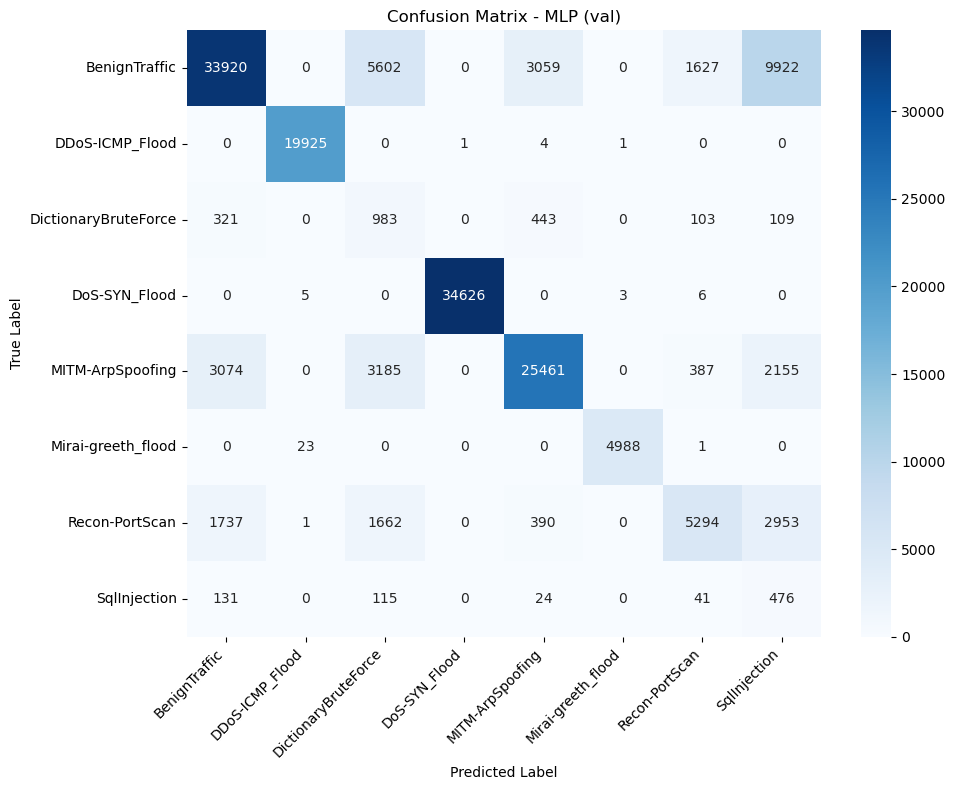

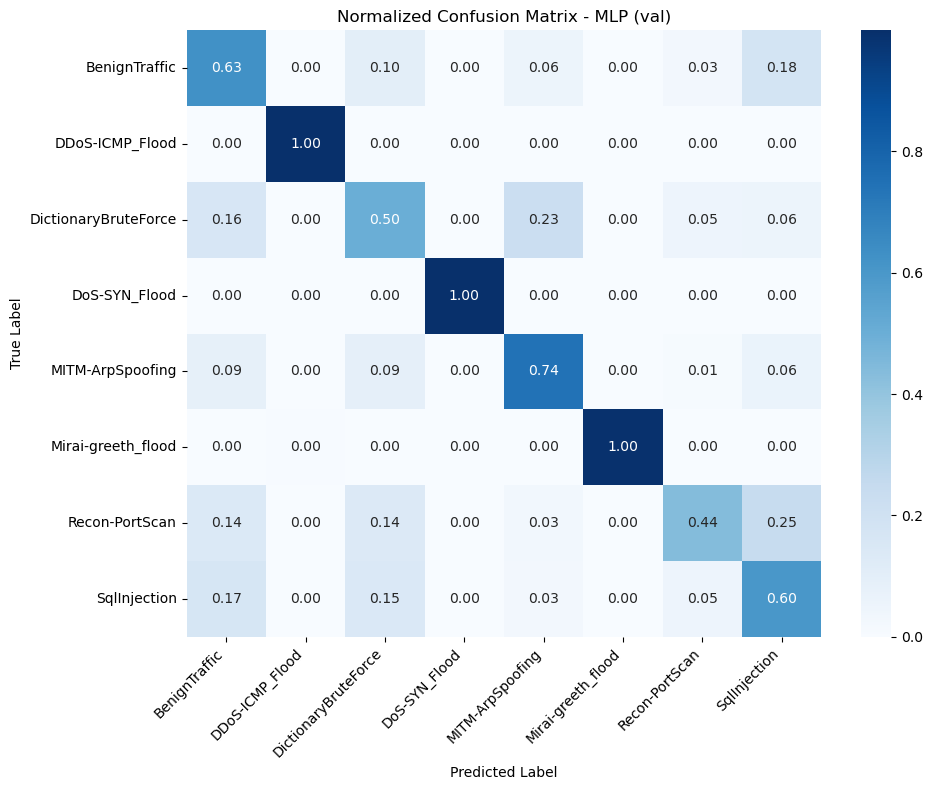

In [24]:
cm_mlp_val = confusion_matrix(y_val, y_val_pred_mlp)
plot_cm(cm_mlp_val, "Confusion Matrix - MLP (val)")
plot_cm(cm_mlp_val, "Normalized Confusion Matrix - MLP (val)", normalize=True)

## 6. Model Comparison & Selection

All four models are compared on the **validation** set. Selection is based on **macro F1**
because the dataset is class-imbalanced and minority attack classes matter. We also track
the **false positive rate on benign** as an operational sanity check — a noisy IDS is not
useful even if its macro F1 looks fine.

In [25]:
models = {
    "Logistic Regression":  (log_reg,   y_val_pred_log),
    "Random Forest":        (rf_model,  y_val_pred_rf),
    "HistGradientBoosting": (gb_model,  y_val_pred_gb),
    "MLP (PyTorch)":        (mlp_model, y_val_pred_mlp),
}

rows = []
for name, (_, y_pred) in models.items():
    rows.append({
        "Model": name,
        "Val Accuracy": accuracy_score(y_val, y_pred),
        "Val Macro F1": f1_score(y_val, y_pred, average="macro"),
        "Val FPR-benign": fpr_on_benign(y_val, y_pred),
    })

comparison_df = (
    pd.DataFrame(rows)
      .sort_values("Val Macro F1", ascending=False)
      .reset_index(drop=True)
)
comparison_df

,Model,Val Accuracy,Val Macro F1,Val FPR-benign
0,Random Forest,0.910100,0.734672,0.025734
1,HistGradientBoosting,0.808083,0.673476,0.303307
2,MLP (PyTorch),0.772146,0.658742,0.373360
3,Logistic Regression,0.685066,0.611777,0.532496


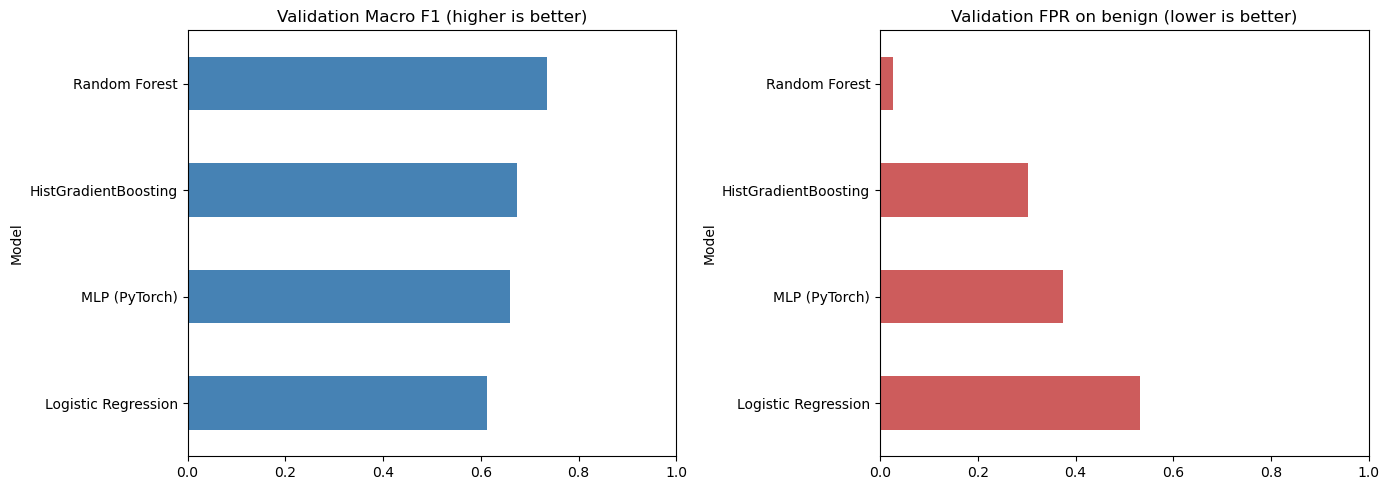

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

comparison_df.plot.barh(
    x="Model", y="Val Macro F1",
    ax=ax[0], legend=False, color="steelblue",
)
ax[0].set_title("Validation Macro F1 (higher is better)")
ax[0].set_xlim(0, 1)
ax[0].invert_yaxis()

comparison_df.plot.barh(
    x="Model", y="Val FPR-benign",
    ax=ax[1], legend=False, color="indianred",
)
ax[1].set_title("Validation FPR on benign (lower is better)")
ax[1].set_xlim(0, 1)
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [27]:
best_name = comparison_df.iloc[0]["Model"]
best_model = models[best_name][0]
print(f"Selected model: {best_name}")

Selected model: Random Forest


## 7. Final Test Evaluation (held-out set)

The test set is evaluated **only** on the single model selected above. This is the number we
report for Milestone 3.

In [28]:
y_test_pred = best_model.predict(X_test)

show_recall_table(
    y_test,
    y_test_pred,
    f"{best_name} - Test",
    class_names,
)

print(f"{best_name} - Test Accuracy:        ", accuracy_score(y_test, y_test_pred))
print(f"{best_name} - Test Macro F1:        ", f1_score(y_test, y_test_pred, average="macro"))
print(f"{best_name} - Test FPR on benign:   ", fpr_on_benign(y_test, y_test_pred))


Random Forest - Test


,class,recall,precision,f1_score,support
7,SqlInjection,0.076239,0.645161,0.136364,787
6,Recon-PortScan,0.410069,0.881271,0.559701,12037
2,DictionaryBruteForce,0.423980,0.845371,0.564730,1960
4,MITM-ArpSpoofing,0.896649,0.967286,0.930629,34262
0,BenignTraffic,0.978053,0.817776,0.890762,54130
3,DoS-SYN_Flood,0.999654,0.999971,0.999812,34640
1,DDoS-ICMP_Flood,0.999950,0.999549,0.999749,19931
5,Mirai-greeth_flood,1.000000,0.999402,0.999701,5013


Random Forest - Test Accuracy:         0.9158331285328091
Random Forest - Test Macro F1:         0.7601809765047548
Random Forest - Test FPR on benign:    0.021947164234250877


In [29]:
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

                      precision    recall  f1-score   support

       BenignTraffic       0.82      0.98      0.89     54130
     DDoS-ICMP_Flood       1.00      1.00      1.00     19931
DictionaryBruteForce       0.85      0.42      0.56      1960
       DoS-SYN_Flood       1.00      1.00      1.00     34640
    MITM-ArpSpoofing       0.97      0.90      0.93     34262
  Mirai-greeth_flood       1.00      1.00      1.00      5013
      Recon-PortScan       0.88      0.41      0.56     12037
        SqlInjection       0.65      0.08      0.14       787

            accuracy                           0.92    162760
           macro avg       0.89      0.72      0.76    162760
        weighted avg       0.92      0.92      0.91    162760



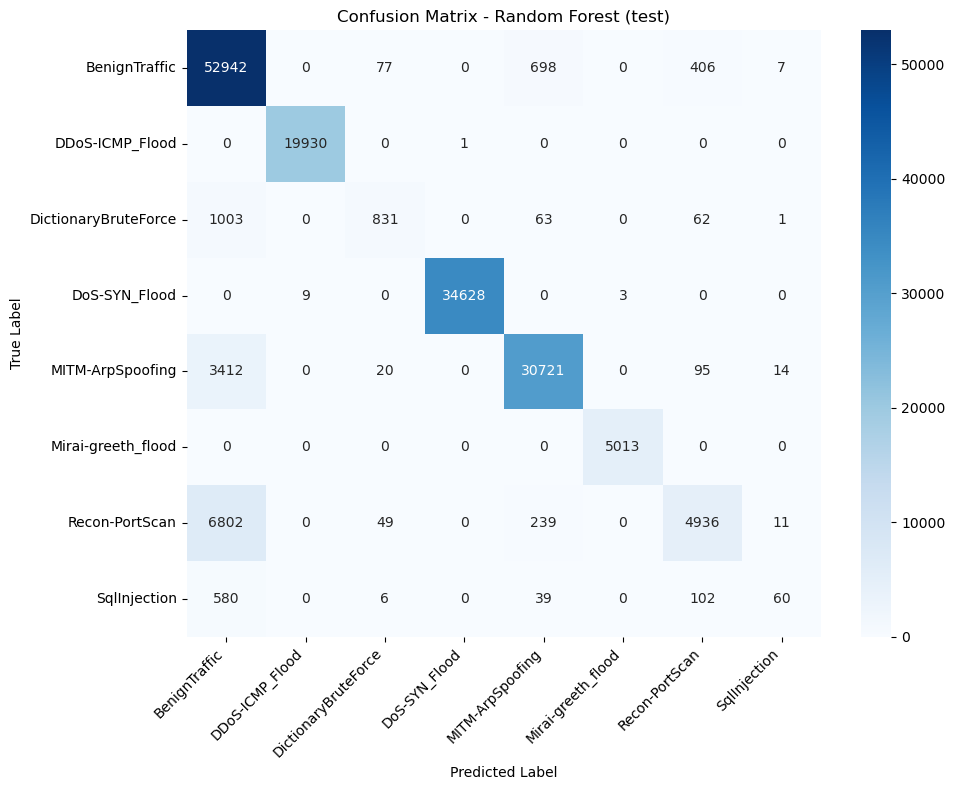

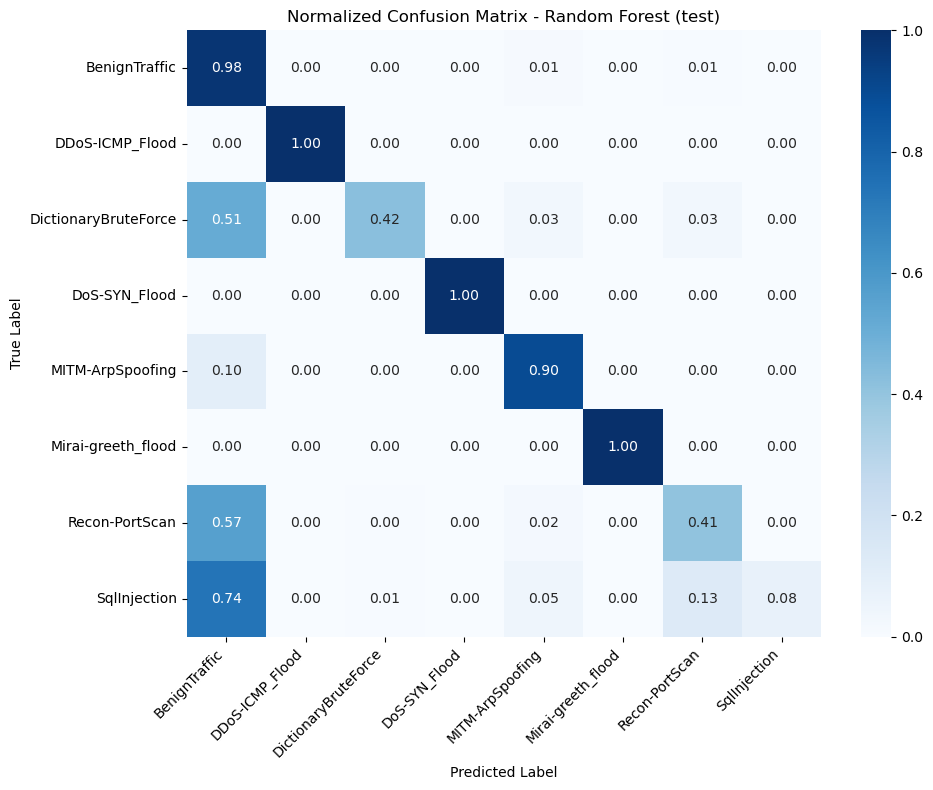

In [30]:
cm_test = confusion_matrix(y_test, y_test_pred)
plot_cm(cm_test, f"Confusion Matrix - {best_name} (test)")
plot_cm(cm_test, f"Normalized Confusion Matrix - {best_name} (test)", normalize=True)

## 8. Save the Selected Model

Saved to `../models/` so Milestone 4 (inference endpoint + drift monitoring) can load it
without retraining. PyTorch models save their `state_dict` to a `.pt` file; scikit-learn
models are pickled with joblib.

In [31]:
import os
import json

os.makedirs("../models", exist_ok=True)

# 1. Save the model itself
if isinstance(best_model, TorchMLPClassifier):
    model_path = "../models/best_model.pt"
    torch.save(
        {
            "state_dict": best_model.model.state_dict(),
            "input_dim": best_model.input_dim,
            "n_classes": best_model.n_classes,
            "hidden_layers": list(best_model.hidden_layers),
        },
        model_path,
    )
else:
    model_path = "../models/best_model.joblib"
    joblib.dump(best_model, model_path)

# 2. Save the class name mapping (label index -> human-readable name)
with open("../models/class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

# 3. Save a metadata file so Milestone 4 knows what it's loading
metadata = {
    "model_name": best_name,
    "model_path": os.path.basename(model_path),
    "model_type": "pytorch" if isinstance(best_model, TorchMLPClassifier) else "sklearn",
    "n_features": int(X_train.shape[1]),
    "n_classes": len(class_names),
    "benign_label": int(BENIGN_LABEL),
    "val_macro_f1":   float(comparison_df.iloc[0]["Val Macro F1"]),
    "val_fpr_benign": float(comparison_df.iloc[0]["Val FPR-benign"]),
    "test_macro_f1":   float(f1_score(y_test, y_test_pred, average="macro")),
    "test_accuracy":   float(accuracy_score(y_test, y_test_pred)),
    "test_fpr_benign": float(fpr_on_benign(y_test, y_test_pred)),
}
with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved {best_name} -> {model_path}")
print("Saved class_names.json and metadata.json")

Saved Random Forest -> ../models/best_model.joblib
Saved class_names.json and metadata.json


In [32]:
print(
    f"Selected model: {best_name}\n"
    f"  Val  — macro F1={comparison_df.iloc[0]['Val Macro F1']:.4f}, "
    f"FPR-benign={comparison_df.iloc[0]['Val FPR-benign']:.4f}\n"
    f"  Test — macro F1={f1_score(y_test, y_test_pred, average='macro'):.4f}, "
    f"accuracy={accuracy_score(y_test, y_test_pred):.4f}, "
    f"FPR-benign={fpr_on_benign(y_test, y_test_pred):.4f}"
)

Selected model: Random Forest
  Val  — macro F1=0.7347, FPR-benign=0.0257
  Test — macro F1=0.7602, accuracy=0.9158, FPR-benign=0.0219


## Conclusion

- All four models were trained with class weighting and evaluated on `X_val`.
- The MLP used a 10% internal split from `X_train` for early stopping, so `X_val`
  stayed pristine for cross-model selection.
- Selection rule: **highest macro F1 on validation** (see `comparison_df`).
- The FPR on benign was tracked at every stage as an operational sanity check — a
  noisy IDS is not operationally useful even if its macro F1 looks fine.
- The test set was touched exactly once, in section 7, on the selected model.
- The selected model, class-name mapping, and metadata are saved under `../models/`
  for Milestone 4 (inference endpoint + drift monitoring).

**Limitations.**
- No hyperparameter tuning or cross-validation — models use fixed defaults.
- Single train/val/test split (ordered per-class 70/15/15 split from Milestone 2).
- Class imbalance is handled via loss weighting; resampling methods (e.g. SMOTE) were
  not explored.